# Assignment 3
### BASIC STATISTICS
By **Mohan Sirumalla**
***


## Descriptive Analytics for Numerical Columns
- Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
- Steps:
	1. Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	2. Identify numerical columns in the dataset.
	3. Calculate the mean, median, mode, and standard deviation for these columns.
	4. Provide a brief interpretation of these statistics.


### 1. Load the dataset into a data analysis tool

In [1]:
# Load the dataset
import pandas as pd 
import numpy as np
from pandas.api.types import is_numeric_dtype
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("sales_data_with_discounts.csv")


In [15]:
df.head() ## comment if not requiremd

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


### 2. Identify numerical columns in the dataset.

In [16]:
# Identify numeric columns using select_dtypes
numeric_cols_df = df.select_dtypes(include=np.number)
# Get the names of the numeric columns
numeric_column_names = numeric_cols_df.columns.tolist()
print(f"\nTotal numeric columns are {len(numeric_column_names)}")
print(f"Names of numeric columns:{numeric_column_names}")



Total numeric columns are 6
Names of numeric columns:['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


### 3. Calculate the mean, median, mode, and standard deviation for these columns.

In [17]:
# Mean,median,mode and standard deviation
numeric_cols = df.select_dtypes(include=np.number).columns

mean_values = df[numeric_cols].mean()
median_values = df[numeric_cols].median()
mode_values = df[numeric_cols].mode().iloc[0]
std_values = df[numeric_cols].std()

print('---- Mean ---\n', mean_values)
print('\n---- Median ----\n', median_values)
print('\n---- Mode ----\n', mode_values)
print('\n---- Standard Deviation ----\n', std_values)

---- Mean ---
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

---- Median ----
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

---- Mode ----
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

---- Standard Deviation ----
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


### 4. Provide a brief interpretation of these statistics.

#### **Interpretation**
**Sales Volume:**\
Mode (3): The most frequent sales volume is 3 units.\
This indicates that the single most common number of items sold per transaction or period is 3.
Median (4): When all sales volumes are ordered from lowest to highest, the middle value is 4 units.
This means half of the sales were 4 units or less, and half were 4 units or more.\
Mean (5): The average sales volume across all data points is 5 units.\
This figure is influenced by the total sales volume and the number of sales instances.\
**Skewness**\
Mean is grater then Median and Mode\
indicates a positive skew (or right skew).

**Sales Price**\
Mode 400 mean most frequest price is 400\
Many items are sold for relatively low price\
Median: Half of the Sales Price is below 1450 and half are above.\
Mean: Average Sales prices is much higher than the median indicates that a few very high-priecd saes are pulling the average upsignificantly\
The sales price (mean = 10453, median = 1450, mode = 400) is right-skewed (also known as positively skewed)\


**Total Sales**\
The  distribution of total sales is highly skewed to the right\
Median: Half of the sales are under 5700 and above 5700\
Mode: Total Sales value that occurs most frequently in the dataset is 24.300\
A large standard deviation relative to the mean (50,535 is greater than 33,812) indicates that the individual sales amounts are widely spread out, not clustered tightly around the average.

**Discount Rate**\
Mode: The most frequesntly occuring discount rate is 5%\
The average of all the discount  rate is 15%\
Median : 50% discount ares are above 16% and 50% discount rates are above 16%\
**Skewness**\
Since the Mean(15) is lessthan the median (16), the distribution of discount rates is negatively skewed\

**Discount Amount**\
The most frequency occuring discount amount is the dataset is 69\
Half of the discount were below 988 abd half were above 988\
The average of all discont amount is 3346\
**Skewness**\
The fact that the mean is much higher than the median suggests that the data s right-skewed

**Net Sales**\
The average of all net sales is 30466\
Half of the discount were below 4677 and half were above 4677\
The most frequently net sales is 326\

**Skewness**\
The distribution of net sales is highly skewed to the right

#### Summary


In [18]:
print ("Summary:")
print(f"Sales of {df['Date'].nunique()} days")
print(f"Total observations are {len(df)}.")
print(f"Total variables are {df.columns.size}.")
print(f"Total Brands sold are {df['Brand'].nunique()}.")
print(f"Total Model sold are {df['Model'].nunique()}.")
print(f"Business Units are {df['BU'].nunique()}.")
total_sales =df['Total Sales Value'].sum()
avg_sales =df['Total Sales Value'].mean()
print(f"Total sales: {total_sales}")
print(f"Average sales: {avg_sales:.2f}")
weekend_sales = df[df['Day'].isin(['Sunday','Saturday'])]['Total Sales Value'].sum()
weekday_sales = df[~df['Day'].isin(['Sunday','Saturday'])]['Total Sales Value'].sum()
print(f"Weekday sales: {weekday_sales}")
print(f"Weekend sales: {weekend_sales}")
print("-"* 30)

Summary:
Sales of 15 days
Total observations are 450.
Total variables are 13.
Total Brands sold are 9.
Total Model sold are 30.
Business Units are 3.
Total sales: 15215776
Average sales: 33812.84
Weekday sales: 11377692
Weekend sales: 3838084
------------------------------


In [19]:
def disp_minmax_summary(df,col,col_disp,col_sum='Volume'):
    temp_groupby = df.groupby(col)[col_sum].sum()
    temp_highest_name = temp_groupby.idxmax()
    temp_highest_value = temp_groupby.max()
    temp_lowest_name = temp_groupby.idxmin()
    temp_lowest_value = temp_groupby.min()
    #print(f"Total sales per Buiness Units:\n{bu_sales}\n")
    print("-"* 30)
    print(f"{col_disp} with the highest {col_sum}: Name {temp_highest_name} ({temp_highest_value})")
    print(f"{col_disp} with the lowest {col_sum}: Name {temp_lowest_name} ({temp_lowest_value})")
# Highets and Lowest Sales cased on category
print("Highest and Lowest:\n")
disp_minmax_summary(df,'BU','Business Unit')
disp_minmax_summary(df,'Date','Date')
disp_minmax_summary(df,'Day','Day')
disp_minmax_summary(df,'BU','Business Unit','Total Sales Value')
disp_minmax_summary(df,'Date','Date','Total Sales Value')
disp_minmax_summary(df,'Day','Day','Total Sales Value')


Highest and Lowest:

------------------------------
Business Unit with the highest Volume: Name FMCG (929)
Business Unit with the lowest Volume: Name Mobiles (641)
------------------------------
Date with the highest Volume: Name 09-04-2021 (170)
Date with the lowest Volume: Name 05-04-2021 (133)
------------------------------
Day with the highest Volume: Name Thursday (436)
Day with the lowest Volume: Name Monday (268)
------------------------------
Business Unit with the highest Total Sales Value: Name Mobiles (13920100)
Business Unit with the lowest Total Sales Value: Name FMCG (397207)
------------------------------
Date with the highest Total Sales Value: Name 01-04-2021 (1199896)
Date with the lowest Total Sales Value: Name 03-04-2021 (858503)
------------------------------
Day with the highest Total Sales Value: Name Thursday (3233312)
Day with the lowest Total Sales Value: Name Saturday (1762126)


In [20]:
def disp_central_ten(df):
    #numeric_cols_df = df.select_dtypes(include=np.number)
    column_names = df.columns.tolist()
    for item in column_names :
        if is_numeric_dtype(df[item])==True:
            temp_mean = df[item].mean()
            temp_median = df[item].median()
            temp_std = df[item].std()
            temp_mode = df[item].mode().iloc[0]
            print(f"{item}=> Mean:{temp_mean:.2f},Median:{temp_median:.2f},mode:{temp_mode:.2f},Standard Deviation:{temp_std:.2f}")

disp_central_ten(df)

Volume=> Mean:5.07,Median:4.00,mode:3.00,Standard Deviation:4.23
Avg Price=> Mean:10453.43,Median:1450.00,mode:400.00,Standard Deviation:18079.90
Total Sales Value=> Mean:33812.84,Median:5700.00,mode:24300.00,Standard Deviation:50535.07
Discount Rate (%)=> Mean:15.16,Median:16.58,mode:5.01,Standard Deviation:4.22
Discount Amount=> Mean:3346.50,Median:988.93,mode:69.18,Standard Deviation:4509.90
Net Sales Value=> Mean:30466.34,Median:4677.79,mode:326.97,Standard Deviation:46358.66


In [21]:
def disp_cat_wise_summary(df):
    non_numeric_cols = df.select_dtypes(exclude=np.number)
    non_numeric_column_names = non_numeric_cols.columns.tolist()
    for item in non_numeric_column_names :
        print(df.groupby(item).agg(Total_Volume=('Volume','sum'),Total_Sales=('Total Sales Value','sum'),Total_Disc=('Discount Amount','sum')))
        print("\n")

In [22]:
# Totals based on each Varaible
disp_cat_wise_summary(df)

            Total_Volume  Total_Sales     Total_Disc
Date                                                
01-04-2021           156      1199896  122057.806000
02-04-2021           167      1129465  112458.672870
03-04-2021           158       858503   84852.853525
04-04-2021           169       989157   96769.167425
05-04-2021           133       903194   87217.056887
06-04-2021           139       965330   91765.785511
07-04-2021           165      1156069  116919.334704
08-04-2021           143      1034291  112019.422959
09-04-2021           170      1067824  108243.056323
10-04-2021           141       903623   87082.506381
11-04-2021           158      1086801  109958.254151
12-04-2021           135       920760   86501.818399
13-04-2021           148      1006077  105853.862989
14-04-2021           161       995661   97014.574471
15-04-2021           137       999125   87210.568358


           Total_Volume  Total_Sales     Total_Disc
Day                                          

In [23]:
# Get the names of the numeric columns
column_names = df.columns.tolist()
print("\nNames of columns:")
print(column_names)


Names of columns:
['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [24]:
# Two-way frequency table
crosstab_sum = pd.crosstab(index=df['Date'], columns=df['BU'],values=df['Total Sales Value'],  aggfunc='sum')
print("\nTwo-way Frequency Table:")
print("Crosstab with Sum (Total Sales):")
print(crosstab_sum)
print("-" * 30)


Two-way Frequency Table:
Crosstab with Sum (Total Sales):
BU           FMCG  Lifestyle  Mobiles
Date                                 
01-04-2021  23501      65995  1110400
02-04-2021  30222      64543  1034700
03-04-2021  31806      60297   766400
04-04-2021  31964      62093   895100
05-04-2021  24798      52096   826300
06-04-2021  20637      66793   877900
07-04-2021  30472      55197  1070400
08-04-2021  19847      62444   952000
09-04-2021  28829      50895   988100
10-04-2021  27678      57445   818500
11-04-2021  25757      64444   996600
12-04-2021  25066      53094   842600
13-04-2021  26282      60295   919500
14-04-2021  28517      63844   903300
15-04-2021  21831      58994   918300
------------------------------


## Data Visualization
**Objective**: To visualize the distribution and relationship of numerical and categorical variables in the dataset
1. **Histograms**:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.
2. **Box Plots**:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.
3. **Bar Chart Analysis for Categorical Column**:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.


### 1. **Histograms**:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.

Bin Edges of Volume:[ 1.  4.  7. 10. 13. 16. 19. 22. 25. 28. 31.]
Bin Edges of Avg Price:[  290.  6271. 12252. 18233. 24214. 30195. 36176. 42157. 48138. 54119.
 60100.]
Bin Edges of Total Sales Value:[   400.  20000.  39600.  59200.  78800.  98400. 118000. 137600. 157200.
 176800. 196400.]
Bin Edges of Discount Rate (%):[ 5.00782219  6.50628067  8.00473916  9.50319765 11.00165613 12.50011462
 13.9985731  15.49703159 16.99549007 18.49394856 19.99240704]
Bin Edges of Discount Amount:[   69.17794229  2636.06236744  5202.94679258  7769.83121773
 10336.71564288 12903.60006802 15470.48449317 18037.36891832
 20604.25334346 23171.13776861 25738.02219376]
Bin Edges of Net Sales Value:[   326.97480055  18245.0252254   36163.07565025  54081.1260751
  71999.17649994  89917.22692479 107835.27734964 125753.32777448
 143671.37819933 161589.42862418 179507.47904902]


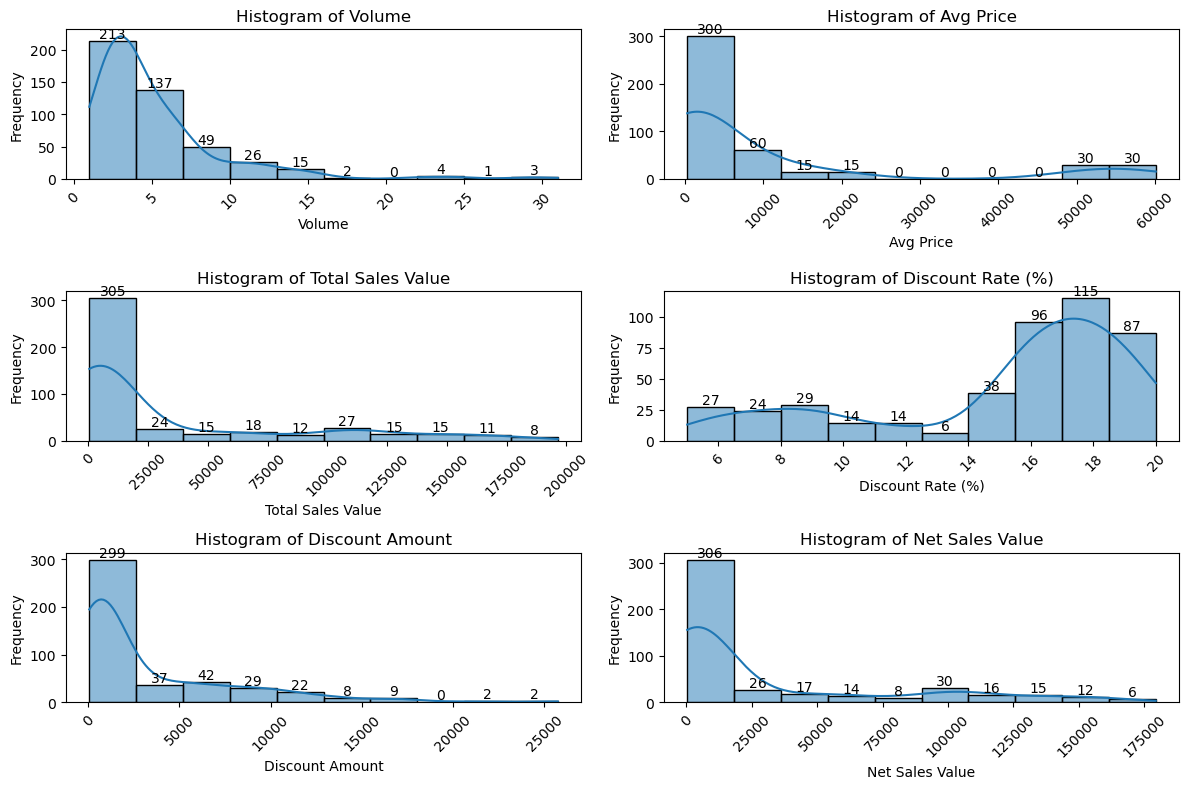

In [25]:
# numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Create subplots in a loop
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    #ax = plt.subplot(1, len(numeric_cols), i + 1) # Create subplot axes in one row
    ax= plt.subplot(len(numeric_cols) // 2 + (len(numeric_cols) % 2), 2, i + 1) # Create subplots
    sns.histplot(data=df, x=col, kde=True, ax=ax,bins=10) # Pass the current ax to histplot
    ax.set_title(f"Histogram of {col}") # Set individual subplot titles
    for p in ax.patches:
        # get the height of the bar (the count)
        height = p.get_height()
        # place the text at the top center of the bar
        ax.text(
            p.get_x() + p.get_width() / 2., # x-coordinate (center of the bar)
            height,                          # y-coordinate (top of the bar)
            f'{int(height)}',                # the label text (integer count)
            ha='center',                     # horizontal alignment
            va='bottom'                      # vertical alignment
        )
    plt.xlabel(col)
    plt.ylabel('Frequency')
    ax.tick_params(axis='x', labelrotation=45)
    # Extract bin edges from the patches
    # The x-coordinate of the start of the first bar is the first edge
    first_edge = ax.patches[0].get_x() 
    # The x-coordinate of the end of each bar is the start of the next one
    # We append the end of the last bar manually
    bin_edges = np.unique([first_edge] + [p.get_x() + p.get_width() for p in ax.patches])
    
    print(f"Bin Edges of {col}:{bin_edges}")
    
   
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()


#### Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.


In [26]:
from scipy.stats import skew
#import numpy as np

for i, col in enumerate(numeric_cols):
    skewness_value = skew(df[col])
    #print(f"The skewness coefficient is: {skewness_value}")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for outliers (1.5 * IQR rule)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers=False
    # Check if any value in the column is outside the bounds
    if ((df[col] < lower_bound) | (df[col] > upper_bound)).any():
        outliers=True

    # Interpretation
    if skewness_value == 0:
        print(f"The distribution of {col} is perfectly symmetric (normal).")
    elif skewness_value > 0:
        print(f"The distribution of {col} is positively (right) skewed.")
    else:
        print(f"The distribution of {col} is negatively (left) skewed.")
    if outliers :
       print(f"The distribution of {col} is having outliers.")

        

The distribution of Volume is positively (right) skewed.
The distribution of Volume is having outliers.
The distribution of Avg Price is positively (right) skewed.
The distribution of Avg Price is having outliers.
The distribution of Total Sales Value is positively (right) skewed.
The distribution of Total Sales Value is having outliers.
The distribution of Discount Rate (%) is negatively (left) skewed.
The distribution of Discount Rate (%) is having outliers.
The distribution of Discount Amount is positively (right) skewed.
The distribution of Discount Amount is having outliers.
The distribution of Net Sales Value is positively (right) skewed.
The distribution of Net Sales Value is having outliers.


#### **Inferences**

Center and Most Common Value: The most frequent volume are between 1 and 4.\
Center and Most Common Value: The most frequent Avg Pric are between 290 and 6271.\
Center and Most Common Value: The most frequent Total Sales Value are between 400 and 20000.\
Center and Most Common Value: The most frequent Discount Rate (%) are between 15.49703159 and 19.99240704.\
Center and Most Common Value: The most frequent Discount Amount are between 69.17794229  2636.06236744.\
Center and Most Common Value: The most frequent Net Sales Value are between 326.97480055  and 18245.0252254.\
Outliers:
The distribution of Volume is having outliers.
The distribution of Avg Price is having outliers.
The distribution of Total Sales Value is having outliers.
The distribution of Discount Rate (%) is having outliers.
The distribution of Discount Amount is having outliers.
The distribution of Net Sales Value is having outliers.

### 2. **Box Plots**:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.

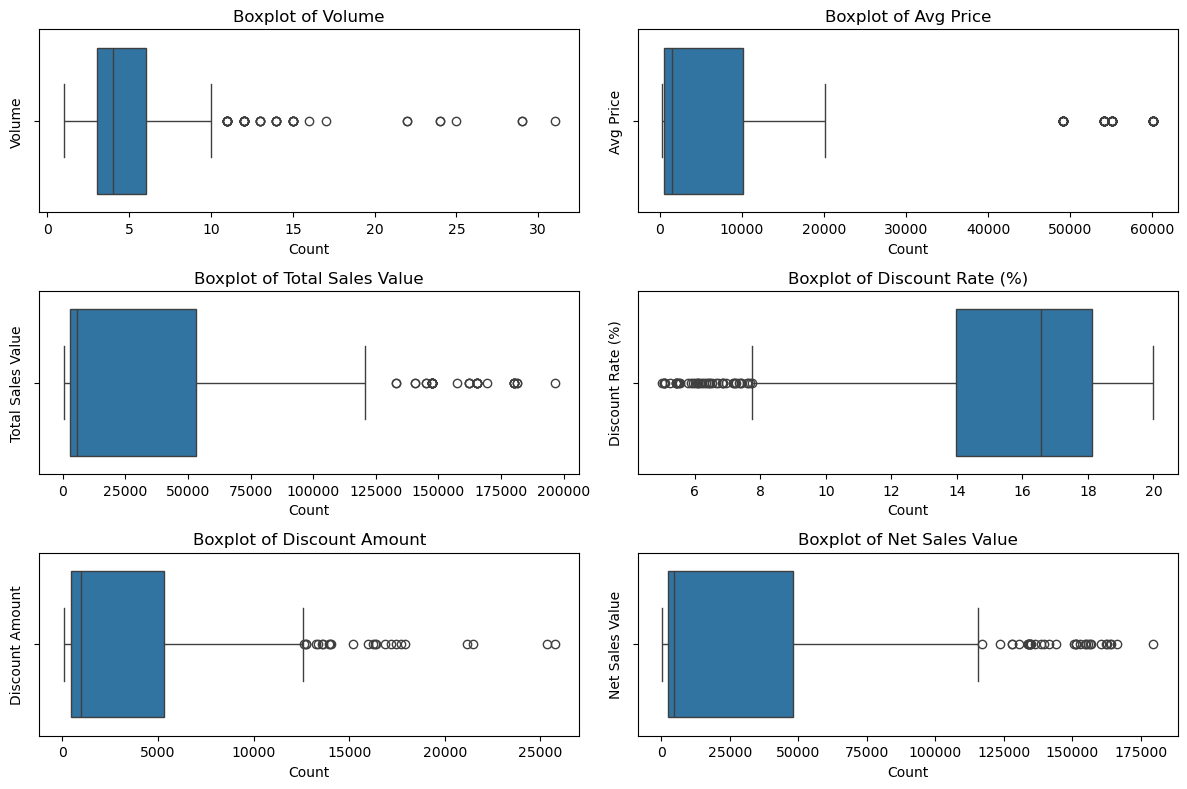

In [27]:
# numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# histogram
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + (len(numeric_cols) % 2), 2, i + 1) # Create subplots
    sns.boxplot(x=df[col], patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.xlabel('Count')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

All the numerical columns are having outliers

### 3. **Bar Chart Analysis for Categorical Column**:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.

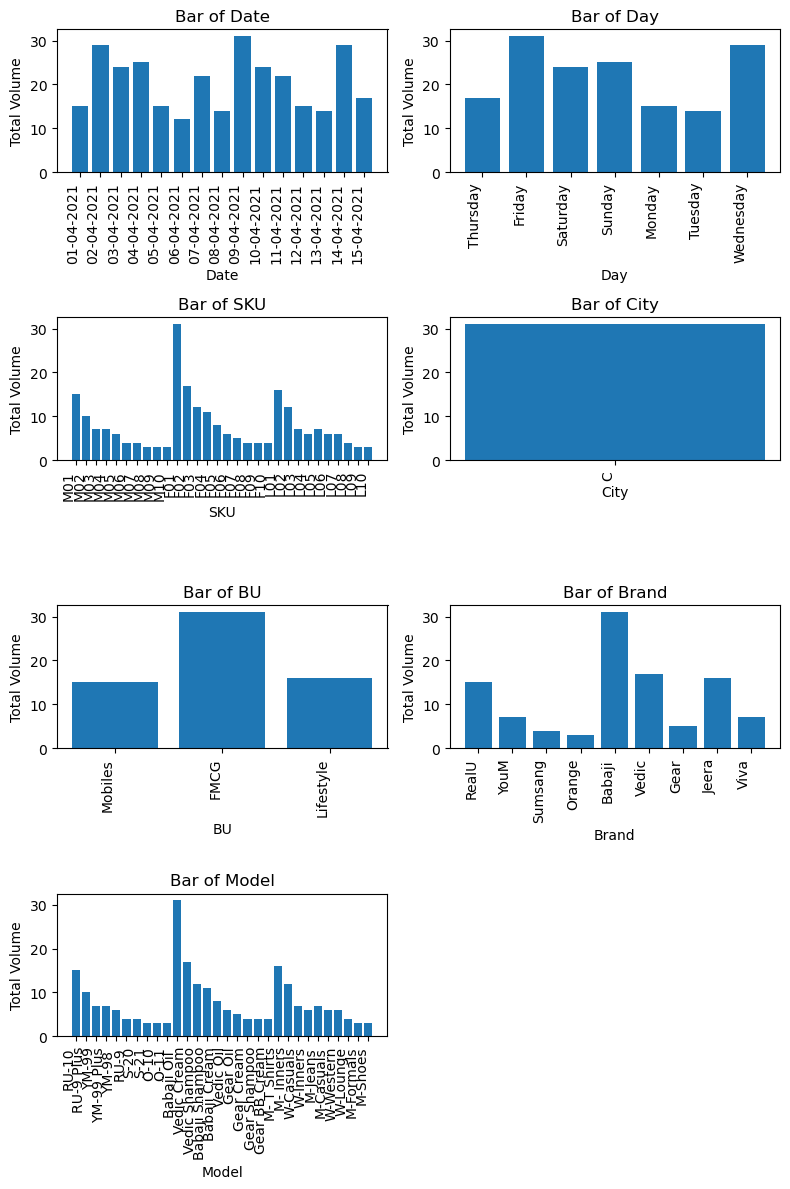

In [28]:
# categorical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

# histogram
plt.figure(figsize=(8, 12)) # Adjust figure size as needed
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols) // 2 + (len(categorical_cols) % 2), 2, i + 1) # Create subplots
    plt.bar(df[col],df['Volume'])
    plt.xticks(rotation=90, ha='right')
    plt.title(f'Bar of {col}')
    plt.xlabel(col)
    plt.ylabel('Total Volume')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()
#disp_minmax_summary(df,'BU','Business Unit')

In [29]:
#disp_minmax_summary(df,'BU','Business Unit')

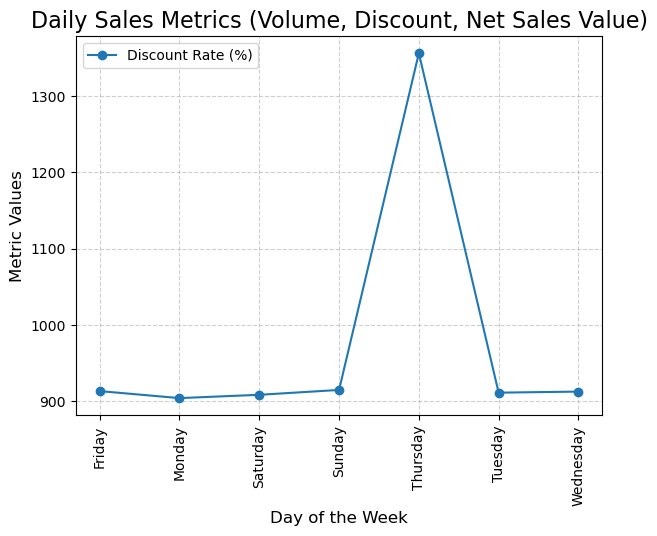

In [62]:
df_vol=df.groupby('Day')['Discount Rate (%)'].sum()
df_vol.plot(kind='line',marker='o')

#plt.plot(df['Day'], df['Volume'], marker='o', label='Volume', color='blue')
#plt.plot(df['Day'], df['Discount Amount'], marker='s', label='Discount', color='red')
#plt.plot(df['Day'], df['Net Sales Value'], marker='^', label='Total Sales', color='green')

# 3. Add labels, title, grid, and legend
plt.title('Daily Sales Metrics (Volume, Discount, Net Sales Value)', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Metric Values', fontsize=12) # A general Y-axis label since values are different scales
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Displays the labels defined in plt.plot()
plt.tight_layout() # Adjusts plot params for tight layout



plt.xticks(rotation=90)
plt.show()


## Conclusion
Summarize the key findings from the descriptive analytics and data visualizations.


Sales are in only 1 City\
Having only 3 units with brands of 9\
Highest Sale is on Thursday and lowest sales on saturday
Sales are related to Discountrate , when discount rate is more, there is more likely the sales will increase


